In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [11]:
import pandas as pd

df_raw = pd.read_csv(r"C:\Users\Rithu Varshini V K\OneDrive\Desktop\Gomma\data_structure\NCRB_Table.csv")
df.head()

,State,Crimes_2020,Crimes_2021,Crimes_2022,Population_Lakhs,Crime_Rate_2022,Chargesheeting_Rate
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,Assam,111558,119883,59315,354.9,167.1,32.6
3,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [12]:
exclude = ['Total State (S)', 'Total UT(S)', 'Total All India']
df = df_raw[~df_raw['State/UT'].isin(exclude)].copy()
df = df.drop(columns=['Sl. No.'])
df = df.reset_index(drop=True)

# Data Conversion

In [13]:
print(f"\nData types:\n{df.dtypes}")


Data types:
State/UT                                            object
2020                                                 int64
2021                                                 int64
2022                                                 int64
Mid-Year Projected Population (in Lakhs) (2022)    float64
Rate of Cognizable Crimes (IPC) (2022)             float64
Chargesheeting Rate (2022)                         float64
dtype: object


In [14]:
df.columns = ['State', 'Crimes_2020', 'Crimes_2021', 'Crimes_2022',
              'Population_Lakhs', 'Crime_Rate_2022', 'Chargesheeting_Rate']
 
# Convert to numeric
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

DATASET OVERVIEW
Shape: (36, 7)

Missing values:
State                  0
Crimes_2020            0
Crimes_2021            0
Crimes_2022            0
Population_Lakhs       0
Crime_Rate_2022        0
Chargesheeting_Rate    0
dtype: int64


In [16]:
print(f"\nData types:\n{df.dtypes}")


Data types:
State                   object
Crimes_2020              int64
Crimes_2021              int64
Crimes_2022              int64
Population_Lakhs       float64
Crime_Rate_2022        float64
Chargesheeting_Rate    float64
dtype: object


# Feature Engineering
- **YoY Change (2021 & 2022):** Percentage increase/decrease in crimes compared to the previous year.
- **Average Crimes:** Mean number of crimes across 2020–2022 for each entry.
- **Crimes per Lakh:** Crime rate normalized by population (per 1 lakh people) for fair comparison.

In [18]:
df['YoY_Change_2021'] = ((df['Crimes_2021'] - df['Crimes_2020']) / df['Crimes_2020']) * 100
df['YoY_Change_2022'] = ((df['Crimes_2022'] - df['Crimes_2021']) / df['Crimes_2021']) * 100
df['Avg_Crimes']      = df[['Crimes_2020','Crimes_2021','Crimes_2022']].mean(axis=1)
df['Crimes_Per_Lakh'] = (df['Crimes_2022'] / df['Population_Lakhs']).round(2)
 

# Descriptive Stats

In [19]:
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe().round(2).to_string())


DESCRIPTIVE STATISTICS
       Crimes_2020  Crimes_2021  Crimes_2022  Population_Lakhs  Crime_Rate_2022  Chargesheeting_Rate  YoY_Change_2021  YoY_Change_2022  Avg_Crimes  Crimes_Per_Lakh
count        36.00        36.00        36.00             36.00            36.00                36.00            36.00            36.00       36.00            36.00
mean     118176.56    101760.00     98927.19            383.26           241.25                67.99            -1.10             5.66   106287.92           241.24
std      176923.51    118652.70    117142.93            497.40           235.52                20.33            19.74            32.54   129314.33           235.50
min         107.00        89.00        64.00              0.70            45.40                10.40           -63.79           -50.71       86.67            45.41
25%        2524.50      2479.75      2934.25             16.08           138.30                57.38            -6.87            -7.29     2636.42          

# Exploratory Data Analysis
- Crime trends show year-wise variation across regions.
- Population has a positive relationship with total crimes.
- Crimes per lakh helps normalize comparisons across regions.
- YoY change highlights sudden spikes or drops in crime.
- Chargesheeting rate indicates effectiveness of law enforcement.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
%matplotlib inline

In [26]:
df.describe()

,Crimes_2020,Crimes_2021,Crimes_2022,Population_Lakhs,Crime_Rate_2022,Chargesheeting_Rate,YoY_Change_2021,YoY_Change_2022,Avg_Crimes,Crimes_Per_Lakh
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,118176.555556,101760.000000,98927.194444,383.261111,241.252778,67.991667,-1.100591,5.661049,106287.916667,241.243333
std,176923.509449,118652.699382,117142.926576,497.400312,235.523156,20.334367,19.738437,32.543588,129314.329748,235.497213
min,107.000000,89.000000,64.000000,0.700000,45.400000,10.400000,-63.793653,-50.706082,86.666667,45.410000
25%,2524.500000,2479.750000,2934.250000,16.075000,138.300000,57.375000,-6.870203,-7.288443,2636.416667,138.320000
50%,50451.500000,47069.000000,46232.000000,255.250000,175.300000,75.350000,2.071826,3.057985,47917.500000,175.260000
75%,165794.250000,163026.250000,157014.000000,566.250000,292.075000,82.425000,8.899647,12.565515,175755.416667,292.097500
max,891700.000000,367218.000000,401787.000000,2340.900000,1424.100000,96.000000,38.052602,141.632653,469488.333333,1423.830000


### Year-wise Crime Trends
- Shows overall trend of crimes across years.
- Helps identify whether crime is increasing or decreasing.
- Useful for detecting long-term patterns.

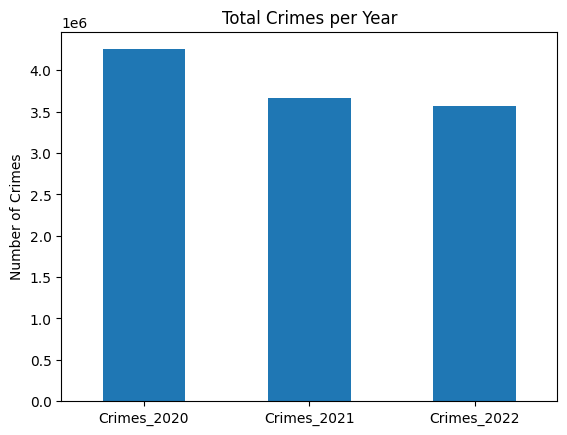

In [28]:
df[['Crimes_2020','Crimes_2021','Crimes_2022']].sum().plot(kind='bar')
plt.title('Total Crimes per Year')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=0)
plt.show()

### Distribution of Crimes (Histograms)
- Displays how crime values are spread across regions.
- Helps identify skewness (left/right).
- Reveals whether most regions have low or high crime.

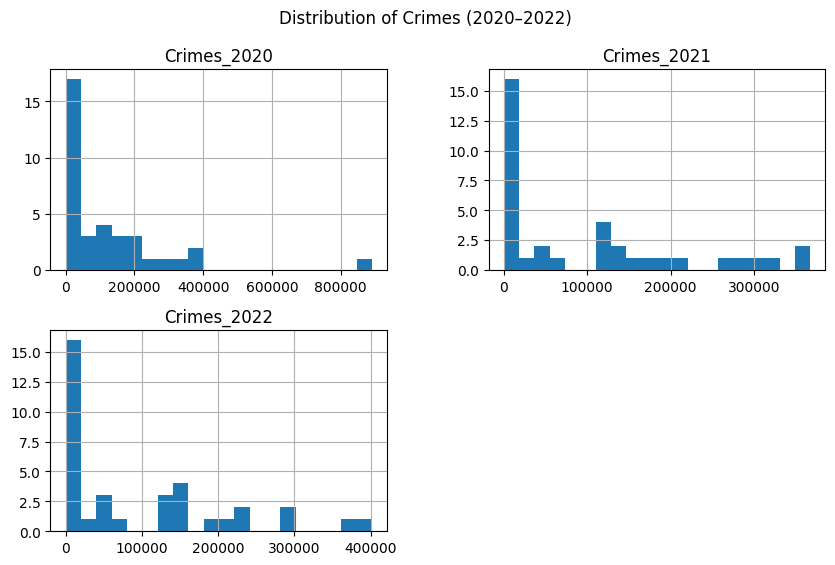

In [29]:
df[['Crimes_2020','Crimes_2021','Crimes_2022']].hist(bins=20, figsize=(10,6))
plt.suptitle('Distribution of Crimes (2020–2022)')
plt.show()

### Box Plot (Outliers Detection)
- Identifies outliers (extremely high/low crime regions).
- Shows median and spread of crime data.
- Useful for detecting abnormal patterns.

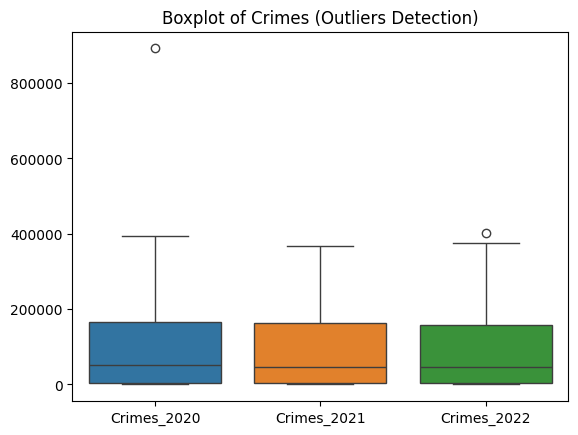

In [30]:
sns.boxplot(data=df[['Crimes_2020','Crimes_2021','Crimes_2022']])
plt.title('Boxplot of Crimes (Outliers Detection)')
plt.show()

### YoY Change Analysis
- Displays distribution of yearly crime growth/decline.
- Helps detect volatility in crime trends.
- Highlights regions with sudden spikes or drops.

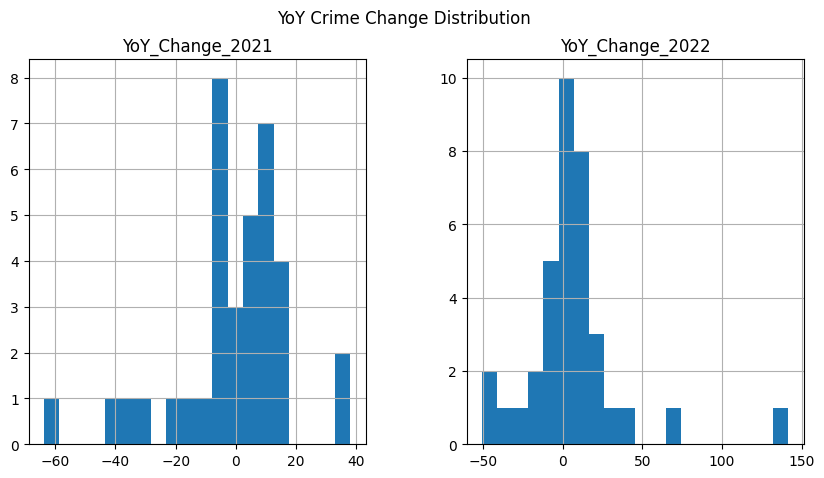

In [31]:
df[['YoY_Change_2021','YoY_Change_2022']].hist(bins=20, figsize=(10,5))
plt.suptitle('YoY Crime Change Distribution')
plt.show()

### Crimes vs Population
- Shows relationship between population and total crimes.
- Helps check if higher population leads to more crime.
- Useful for understanding scaling effects.

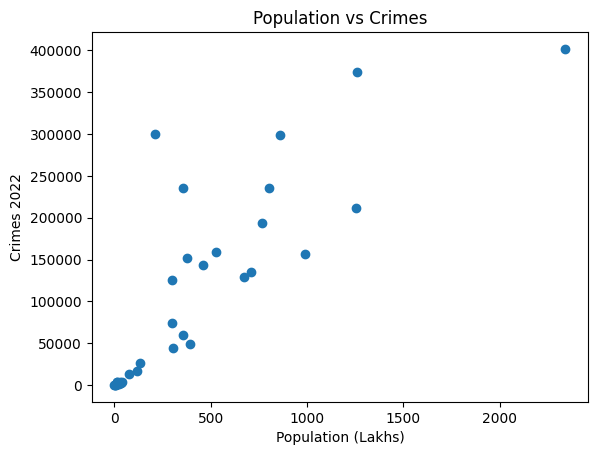

In [32]:
plt.scatter(df['Population_Lakhs'], df['Crimes_2022'])
plt.xlabel('Population (Lakhs)')
plt.ylabel('Crimes 2022')
plt.title('Population vs Crimes')
plt.show()

### Crimes per Lakh Distribution
- Normalizes crime data by population.
- Allows fair comparison across regions.
- Highlights high-risk areas independent of population size.

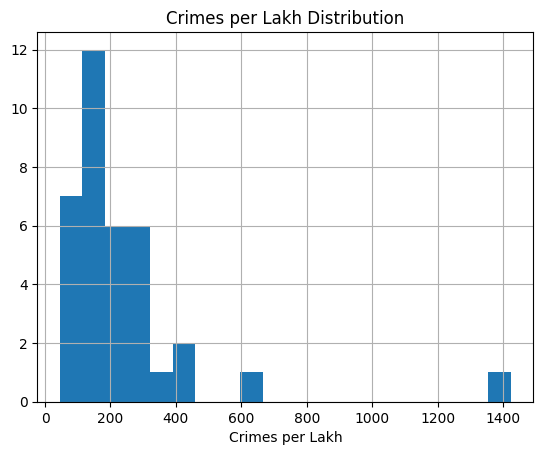

In [33]:
df['Crimes_Per_Lakh'].hist(bins=20)
plt.title('Crimes per Lakh Distribution')
plt.xlabel('Crimes per Lakh')
plt.show()

### Crime Rate vs Chargesheeting Rate
- Shows relationship between crime rate and law enforcement efficiency.
- Helps evaluate effectiveness of policing.
- Can reveal inverse or direct relationships.

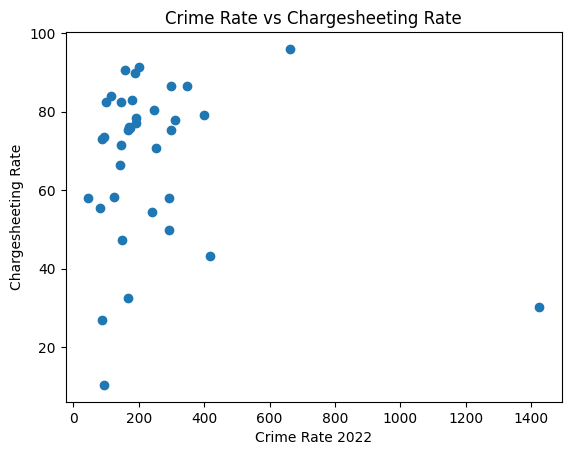

In [34]:
plt.scatter(df['Crime_Rate_2022'], df['Chargesheeting_Rate'])
plt.xlabel('Crime Rate 2022')
plt.ylabel('Chargesheeting Rate')
plt.title('Crime Rate vs Chargesheeting Rate')
plt.show()

### Average Crimes Distribution
- Represents overall crime level across years.
- Smooths yearly fluctuations.
- Useful for identifying consistently high-crime regions.

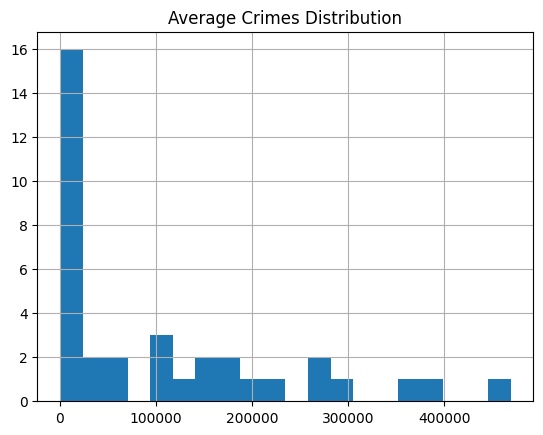

In [35]:
df['Avg_Crimes'].hist(bins=20)
plt.title('Average Crimes Distribution')
plt.show()

### Pair Plots
- Visualizes relationships between all variables.
- Helps detect trends, clusters, and correlations.
- Useful for comprehensive exploratory analysis.

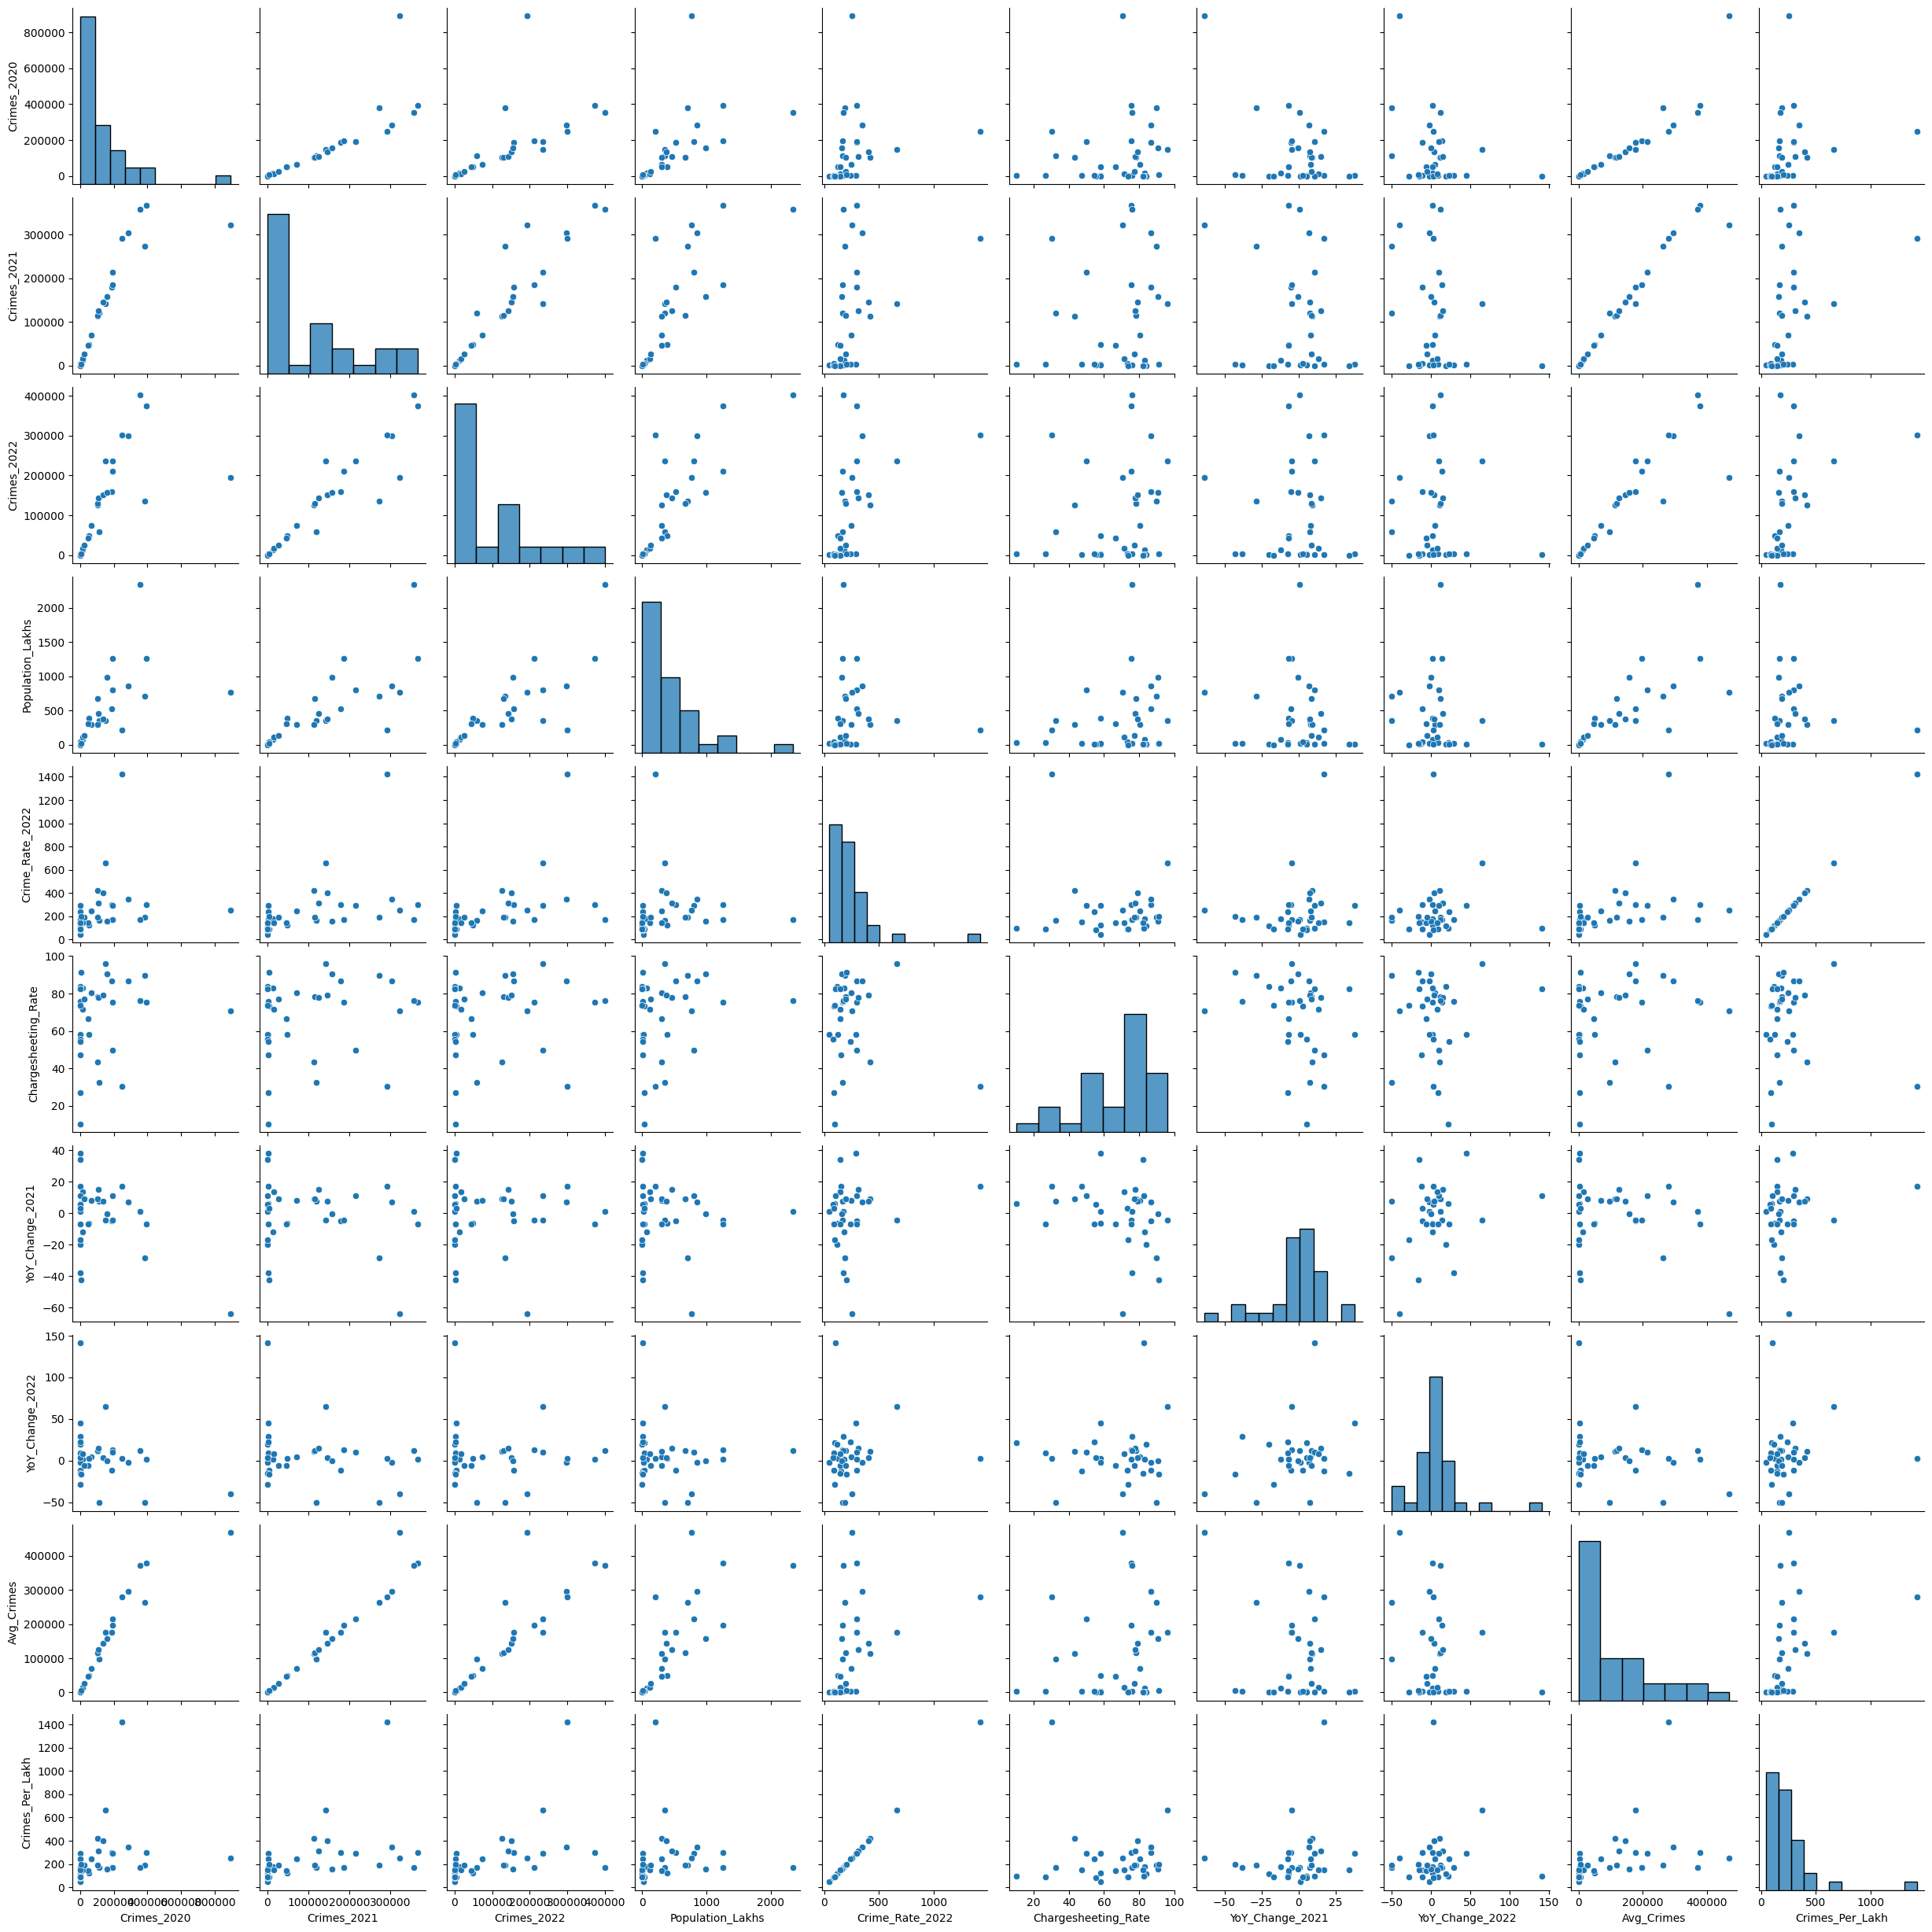

In [36]:
sns.pairplot(df)
plt.show()

### YoY Change Comparison (Bar)
- Compares crime growth across years.
- Helps identify consistency or fluctuations.
- Useful for trend comparison between periods.

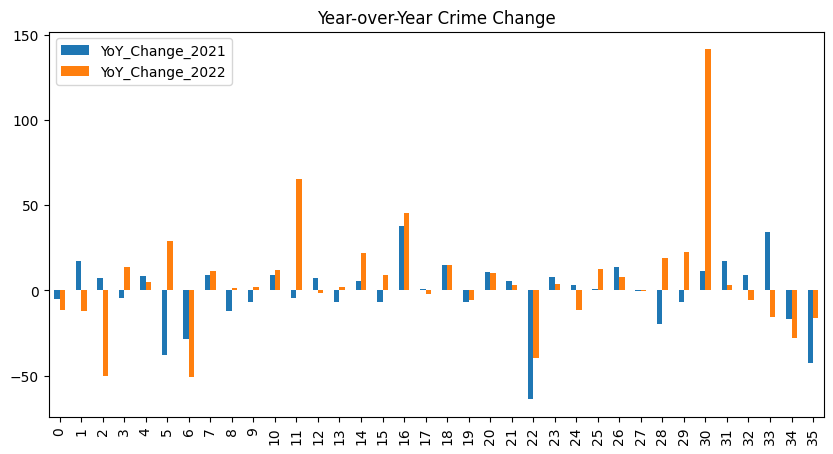

In [37]:
df[['YoY_Change_2021','YoY_Change_2022']].plot(kind='bar', figsize=(10,5))
plt.title('Year-over-Year Crime Change')
plt.show()

### Chargesheeting Rate Distribution
- Shows how effectively cases are being processed.
- Helps identify regions with weak enforcement.
- Useful for justice system performance analysis.

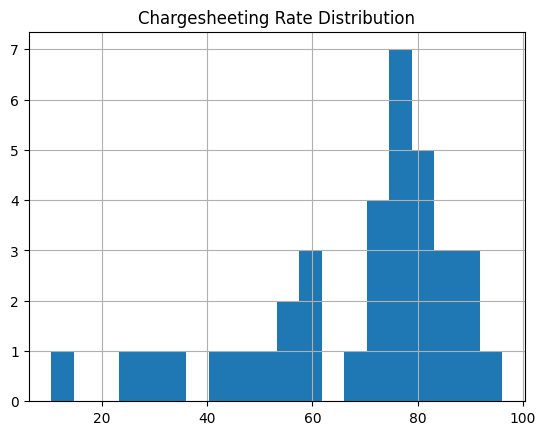

In [38]:
df['Chargesheeting_Rate'].hist(bins=20)
plt.title('Chargesheeting Rate Distribution')
plt.show()

# Correlation Matrix

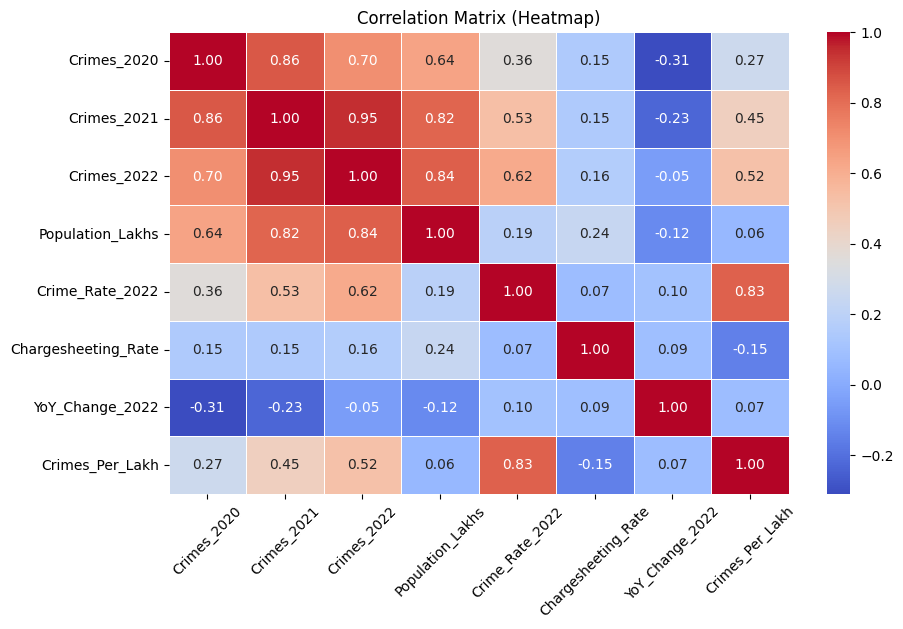

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['Crimes_2020','Crimes_2021','Crimes_2022','Population_Lakhs',
             'Crime_Rate_2022','Chargesheeting_Rate','YoY_Change_2022','Crimes_Per_Lakh']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Matrix (Heatmap)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Outlier  Detection and Removal
- Outliers were identified using the Interquartile Range (IQR) method.
- Values lying below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered outliers.
- Instead of removing, outliers were capped to the lower and upper bounds.
- This approach preserves data while reducing the influence of extreme values.
- Helps improve data quality and model performance.

In [42]:

for col in ['Crimes_2022', 'Crime_Rate_2022', 'Chargesheeting_Rate']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace directly in df (in-place)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

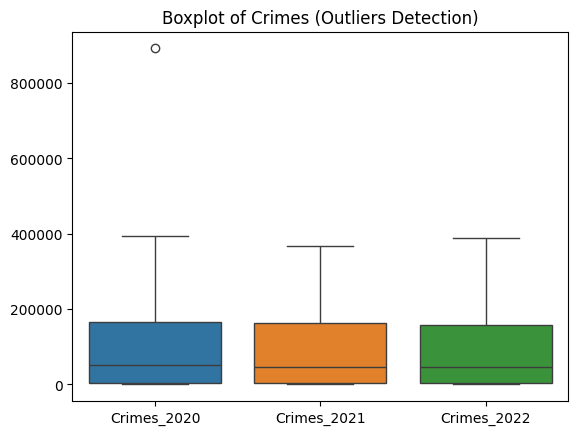

In [43]:
sns.boxplot(data=df[['Crimes_2020','Crimes_2021','Crimes_2022']])
plt.title('Boxplot of Crimes (Outliers Detection)')
plt.show()

# Data Skew and Kurtosis
- Skewness and kurtosis were analyzed to understand data distribution.
- Features with high skewness were transformed using log transformation.
- This helps make the data more normally distributed.
- Reduces the impact of extreme values and improves model performance.
- Post-transformation distributions are more symmetric and stable.

In [47]:
features = ['Crimes_2020','Crimes_2021','Crimes_2022','Population_Lakhs', 'Crime_Rate_2022','Chargesheeting_Rate','Avg_Crimes','Crimes_Per_Lakh']

In [51]:
print("\n" + "=" * 60)
print("SKEWNESS")
print("=" * 60)
print(df[features].skew().sort_values(ascending=False))

print("\n" + "=" * 60)
print("KURTOSIS")
print("=" * 60)
print(df[features].kurtosis().sort_values(ascending=False))


SKEWNESS
Crimes_Per_Lakh        3.941460
Crimes_2020            2.719400
Population_Lakhs       2.111921
Avg_Crimes             1.219300
Crime_Rate_2022        1.118603
Crimes_2022            1.064502
Crimes_2021            0.964905
Chargesheeting_Rate   -0.947494
dtype: float64

KURTOSIS
Crimes_Per_Lakh        18.717613
Crimes_2020             9.735137
Population_Lakhs        5.801619
Crime_Rate_2022         0.904020
Avg_Crimes              0.700688
Crimes_2022             0.155490
Chargesheeting_Rate     0.104294
Crimes_2021            -0.309371
dtype: float64


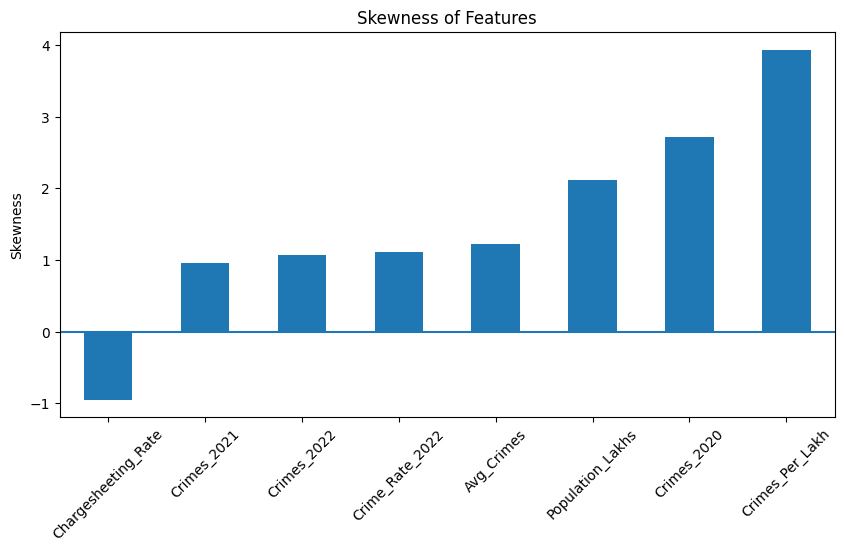

In [49]:
import matplotlib.pyplot as plt

skew_vals = df[features].skew().sort_values()

plt.figure(figsize=(10,5))
skew_vals.plot(kind='bar')

plt.axhline(0)  # zero reference line
plt.title("Skewness of Features")
plt.ylabel("Skewness")
plt.xticks(rotation=45)

plt.show()

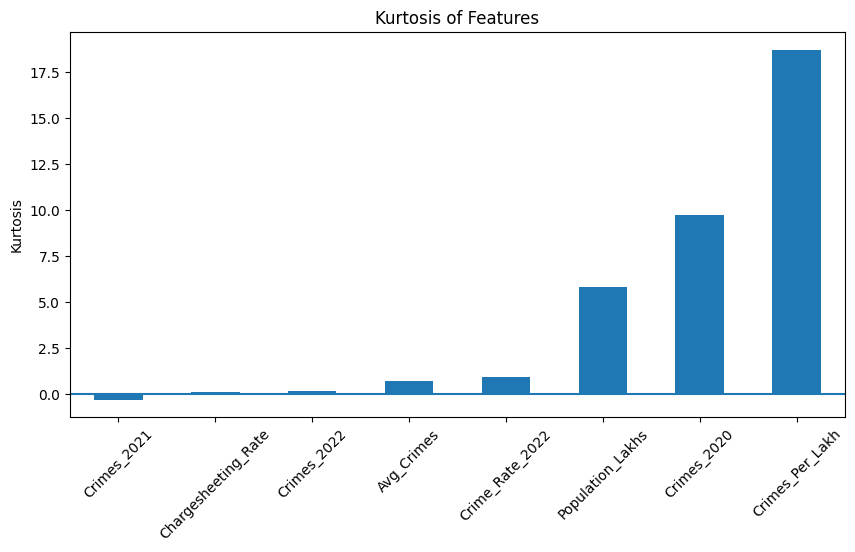

In [50]:
kurt_vals = df[features].kurtosis().sort_values()

plt.figure(figsize=(10,5))
kurt_vals.plot(kind='bar')

plt.axhline(0)  # zero reference line
plt.title("Kurtosis of Features")
plt.ylabel("Kurtosis")
plt.xticks(rotation=45)

plt.show()

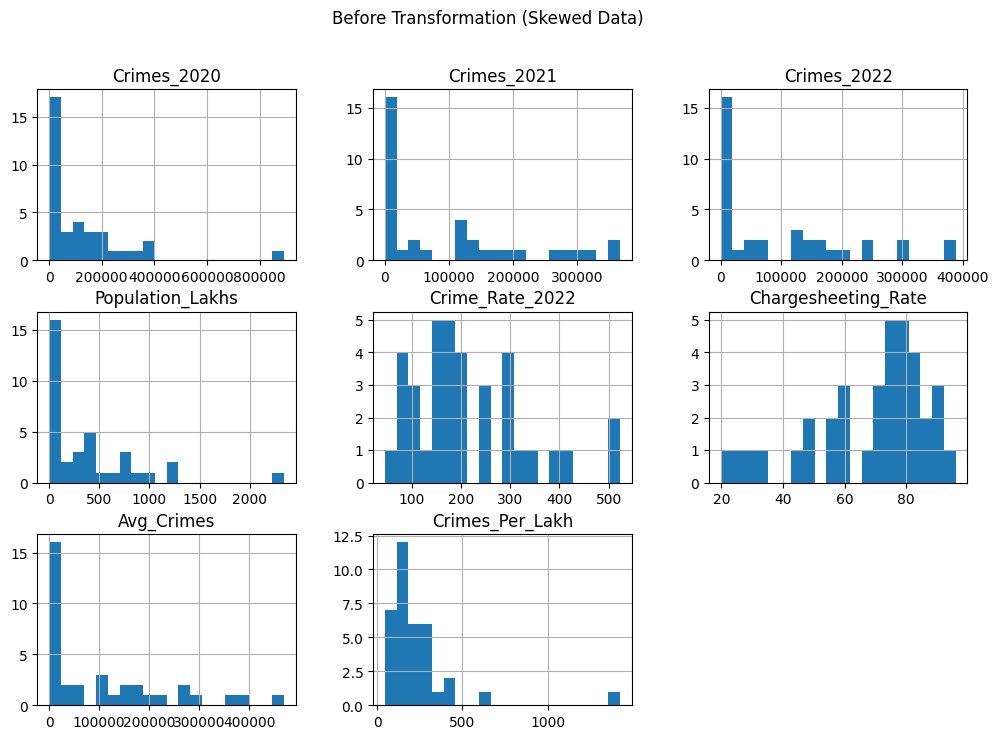

In [52]:
import matplotlib.pyplot as plt

df[features].hist(bins=20, figsize=(12,8))
plt.suptitle("Before Transformation (Skewed Data)")
plt.show()

In [55]:
import numpy as np

df_transformed = df.copy()

for col in features:
    if abs(df_transformed[col].skew()) > 1:  # highly skewed
        df_transformed[col] = np.log1p(df_transformed[col])

for col in features:
    if abs(df[col].skew()) > 1:  # highly skewed
        df[col] = np.log1p(df[col])


In [57]:
print("\n" + "=" * 60)
print("SKEWNESS AFTER FIX")
print("=" * 60)
print(df[features].skew().sort_values(ascending=False))

print("\n" + "=" * 60)
print("KURTOSIS AFTER FIX")
print("=" * 60)
print(df[features].kurtosis().sort_values(ascending=False))


SKEWNESS AFTER FIX
Crimes_2021            0.964905
Crimes_Per_Lakh        0.696418
Crime_Rate_2022       -0.136303
Population_Lakhs      -0.421443
Crimes_2020           -0.435619
Avg_Crimes            -0.481239
Crimes_2022           -0.533452
Chargesheeting_Rate   -0.947494
dtype: float64

KURTOSIS AFTER FIX
Crimes_Per_Lakh        1.861299
Chargesheeting_Rate    0.104294
Crime_Rate_2022       -0.117365
Crimes_2021           -0.309371
Crimes_2022           -0.919248
Population_Lakhs      -1.058728
Avg_Crimes            -1.094052
Crimes_2020           -1.122795
dtype: float64


# Normalization

In [58]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

df[features] = scaler_std.fit_transform(df[features])

print("\n" + "=" * 60)
print("Z-SCORE NORMALIZED DATA (first 5 rows)")
print("=" * 60)
print(df[['State'] + features[:4]].head().to_string())


print("\n" + "=" * 60)
print("FINAL DESCRIPTION (After Standard Scaling)")
print("=" * 60)
print(df[features].describe().round(3).to_string())


Z-SCORE NORMALIZED DATA (first 5 rows)
               State  Crimes_2020  Crimes_2021  Crimes_2022  Population_Lakhs
0     Andhra Pradesh     0.895035     0.665432     0.858248          0.799406
1  Arunachal Pradesh    -0.901006    -0.847349    -0.906967         -0.999490
2              Assam     0.681447     0.154907     0.447886          0.591807
3              Bihar     0.907075     0.720094     0.977695          1.245300
4       Chhattisgarh     0.463949    -0.267033     0.539206          0.504140

FINAL DESCRIPTION (After Standard Scaling)
       Crimes_2020  Crimes_2021  Crimes_2022  Population_Lakhs  Crime_Rate_2022  Chargesheeting_Rate  Avg_Crimes  Crimes_Per_Lakh
count       36.000       36.000       36.000            36.000           36.000               36.000      36.000           36.000
mean        -0.000       -0.000       -0.000            -0.000           -0.000               -0.000      -0.000            0.000
std          1.014        1.014        1.014             1

# Model Training

In [59]:
X = df[['Population_Lakhs','Crime_Rate_2022','Chargesheeting_Rate',
        'Crimes_2020','Crimes_2021']].values
y = df['Crimes_2022'].values
 
models = {
    'Linear Regression':       LinearRegression(),
    'Ridge (α=1)':             Ridge(alpha=1),
    'Lasso (α=1)':             Lasso(alpha=500, max_iter=10000),
    'ElasticNet':              ElasticNet(alpha=500, l1_ratio=0.5, max_iter=10000),
    'Decision Tree':           DecisionTreeRegressor(max_depth=3, random_state=42),
    'Random Forest':           RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':       GradientBoostingRegressor(n_estimators=100, random_state=42),
}
 

In [60]:
results = []
loo = LeaveOneOut()

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    print(f"\n{name}")
    print(f"  Test R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")


Linear Regression
  Test R²=0.9753  RMSE=0.16  MAE=0.10

Ridge (α=1)
  Test R²=0.9830  RMSE=0.14  MAE=0.10

Lasso (α=1)
  Test R²=-0.0148  RMSE=1.05  MAE=0.97

ElasticNet
  Test R²=-0.0148  RMSE=1.05  MAE=0.97

Decision Tree
  Test R²=0.8420  RMSE=0.41  MAE=0.32

Random Forest
  Test R²=0.9730  RMSE=0.17  MAE=0.15

Gradient Boosting
  Test R²=0.9627  RMSE=0.20  MAE=0.19


In [64]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['Linear Regression','Ridge','Lasso','ElasticNet',
              'Decision Tree','Random Forest','Gradient Boosting'],
    'R2': [0.9753,0.9830,-0.0148,-0.0148,0.8420,0.9730,0.9627],
    'RMSE': [0.16,0.14,1.05,1.05,0.41,0.17,0.20],
    'MAE': [0.10,0.10,0.97,0.97,0.32,0.15,0.19]
})

### R2 Comparision
- R² score indicates how well the model explains the variance in the data.
- Higher R² values (closer to 1) represent better model performance.
- Ridge Regression achieved the highest R², making it the best-performing model.
- Linear Regression and Random Forest also show strong predictive capability.
- Lasso and ElasticNet have very low/negative R², indicating poor model fit and underfitting.

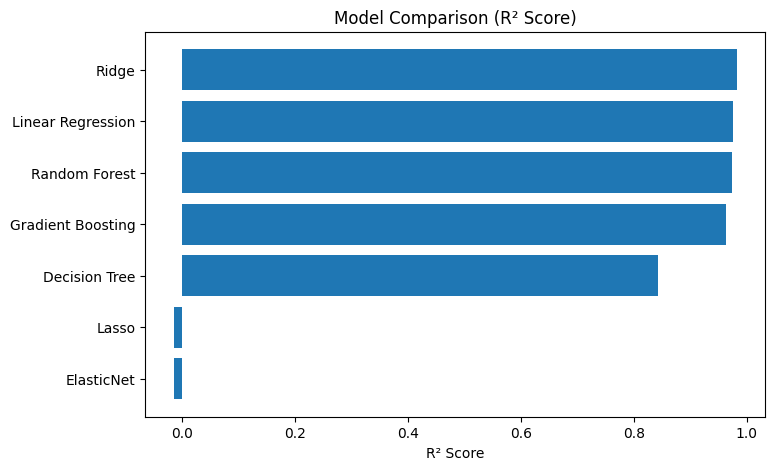

In [65]:
import matplotlib.pyplot as plt

results_df.sort_values('R2', inplace=True)

plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['R2'])

plt.title("Model Comparison (R² Score)")
plt.xlabel("R² Score")

plt.show()

### RMSE Comparision
- RMSE measures the average magnitude of prediction error.
- Lower RMSE values indicate better model accuracy.
- Ridge Regression has the lowest RMSE, confirming its superior performance.
- Tree-based models (Decision Tree, Random Forest) have moderate error levels.
- Lasso and ElasticNet show very high RMSE, indicating large prediction errors.

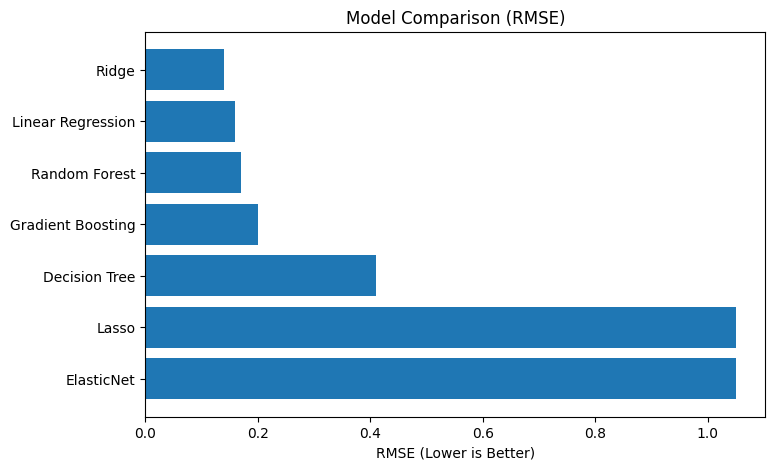

In [66]:
plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['RMSE'])

plt.title("Model Comparison (RMSE)")
plt.xlabel("RMSE (Lower is Better)")

plt.show()

### MAE Comparision
- MAE represents the average absolute difference between predicted and actual values.
- Lower MAE indicates more accurate and consistent predictions.
- Ridge and Linear Regression have the lowest MAE, showing stable performance.
- Random Forest performs reasonably well with slightly higher error.
- Lasso and ElasticNet have very high MAE, indicating poor prediction quality.

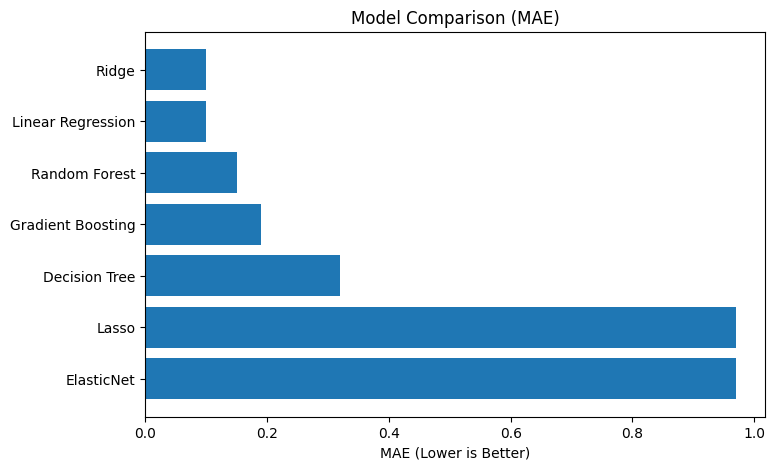

In [67]:
plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['MAE'])

plt.title("Model Comparison (MAE)")
plt.xlabel("MAE (Lower is Better)")

plt.show()

### Combined Plots
- Ridge Regression consistently performs best across all evaluation metrics.
- Linear models outperform complex models in this dataset.
- Regularization strength significantly affects model performance (Lasso underfits).
- Simpler models may be more suitable for this dataset.

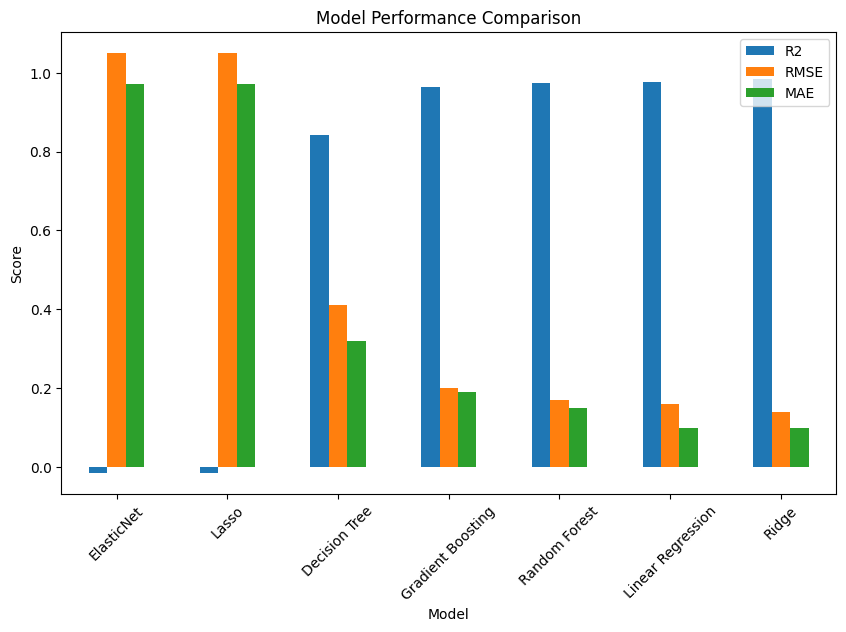

In [68]:
results_df.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.ylabel("Score")

plt.show()

# Feature Importance
- Feature importance indicates how much each variable contributes to the model’s predictions.
- Higher importance values mean the feature has a greater impact on predicting the target.
- The model relies more on top-ranked features for decision-making.
- Lower-ranked features have minimal influence and may be less significant.

In [69]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
feature_names = ['Population','Crime Rate','Chargesheeting Rate','Crimes 2020','Crimes 2021']
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
 
print("\n" + "=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCES")
print("=" * 60)
print(importances.round(4).to_string())


RANDOM FOREST FEATURE IMPORTANCES
Population             0.3563
Crimes 2021            0.3555
Crimes 2020            0.2783
Crime Rate             0.0058
Chargesheeting Rate    0.0040
